## Unilingual Model Exploration

This section explores unilingual models (Ensemble methods) that uses one model per language


---
Note that cross-validation process differs if we use a multi-lingual model or mono-lingual model:
- Multi-Lingual: Each fold should contain all the nodes with the same sentence_id and for all languages! (To avoid unbalance)
- Uni-Lingual: Each fold should contain all the the nodes with the same sentence_id. There are 2 ways to do this:

In [1]:
from src.unilingual_ensemble import UnilingualEnsembleClassifier
from src.cross_validation import *

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

train = pd.read_csv("./data/train_dataset_processed.csv")
test = pd.read_csv("./data/test_dataset_processed.csv")
train

,sentence_id,language,node,degree_centrality,harmonic_centrality,betweenness_centrality,pagerank_centrality,root
0,2,Japanese,6,0.090909,5.823846,0.090909,0.048565,0
1,2,Japanese,4,0.045455,4.561122,0.000000,0.027162,0
2,2,Japanese,2,0.136364,6.991703,0.255411,0.066901,0
3,2,Japanese,23,0.045455,5.157179,0.000000,0.025477,0
4,2,Japanese,20,0.090909,7.146825,0.311688,0.042552,0
...,...,...,...,...,...,...,...,...
197474,995,Russian,19,0.055556,5.005159,0.000000,0.032147,0
197475,995,Russian,1,0.055556,6.034524,0.000000,0.029739,0
197476,995,Russian,14,0.055556,6.034524,0.000000,0.029739,0
197477,995,Russian,5,0.111111,6.701190,0.111111,0.057065,0


### Model 1: Random Forest Ensemble

In [11]:
model = UnilingualEnsembleClassifier(base_model_cls=RandomForestClassifier, base_model_kwargs={}, language_colname="language", n_jobs=21)
model.fit(X=train.drop(columns="root", inplace=False),y=train["root"])

UnilingualEnsembleClassifier(base_model_kwargs={}, n_jobs=21)

2025-05-20 19:57:05.359 | INFO     | src.cross_validation:run_groupkfold_cv:60 - [Fold 1] accuracy_score: 1.0000
2025-05-20 19:57:17.518 | INFO     | src.cross_validation:run_groupkfold_cv:60 - [Fold 2] accuracy_score: 1.0000
2025-05-20 19:57:24.856 | INFO     | src.cross_validation:run_groupkfold_cv:60 - [Fold 3] accuracy_score: 1.0000
2025-05-20 19:57:32.638 | INFO     | src.cross_validation:run_groupkfold_cv:60 - [Fold 4] accuracy_score: 1.0000
2025-05-20 19:57:38.949 | INFO     | src.cross_validation:run_groupkfold_cv:60 - [Fold 5] accuracy_score: 1.0000
2025-05-20 19:57:38.949 | INFO     | src.cross_validation:run_groupkfold_cv:63 - 
Mean accuracy_score over 5 folds: 1.0000


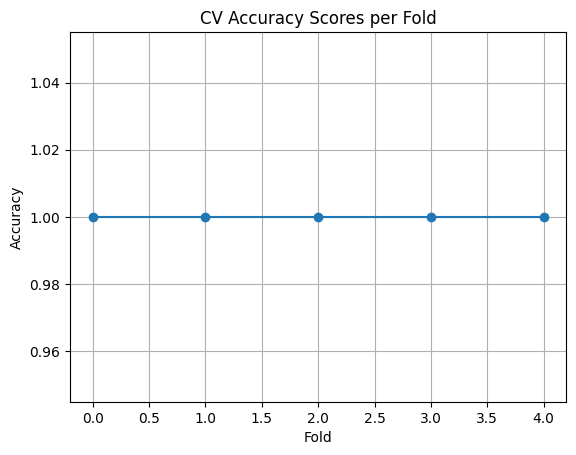

/home/wtroiani/miniconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Predicted 194648 test samples.
Sample predictions: [0 0 0 0 0 0 0 0 0 0]


In [2]:
# Imports
from src.unilingual_ensemble import UnilingualEnsembleClassifier
from src.cross_validation import run_groupkfold_cv
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
train = pd.read_csv("./data/train_dataset_processed.csv")
test = pd.read_csv("./data/test_dataset_processed.csv")

# Make sure 'root' is your target and 'sentence_id' groups sentences (adjust if needed)
target_col = "root"
group_col = "sentence_id"  # replace if different in your dataset

# Run GroupKFold CV on train
cv_scores = run_groupkfold_cv(
    X=train,
    y=train[target_col],
    group_colname=group_col,
    clf_cls=UnilingualEnsembleClassifier,
    clf_kwargs={
        'base_model_cls': RandomForestClassifier,
        'base_model_kwargs': {'n_estimators': 200, 'n_jobs': 1},
        'language_colname': 'language',
        'n_jobs': 8  # adjust based on your CPU
    },
    n_splits=5,
    metric_fn=accuracy_score,
    verbose=True
)

# Plot CV scores
plt.plot(cv_scores, marker='o')
plt.title('CV Accuracy Scores per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Train final model on full train data
model = UnilingualEnsembleClassifier(
    base_model_cls=RandomForestClassifier,
    base_model_kwargs={'n_estimators': 100, 'n_jobs': 1},
    language_colname='language',
    n_jobs=8
)
model.fit(train.drop(columns=target_col), train[target_col])

# Predict on test
test_preds = model.predict(test)

# If test has true labels, evaluate; otherwise just show predictions count
if target_col in test.columns:
    test_acc = accuracy_score(test[target_col], test_preds)
    print(f"Test Accuracy: {test_acc:.4f}")
else:
    print(f"Predicted {len(test_preds)} test samples.")

# Show a few predictions
print("Sample predictions:", test_preds[:10])


### Send this shit to kaggle

In [13]:
# === Prepare Kaggle Submission === #

# Attach predictions to test DataFrame
test = test.copy()
test["root"] = test_preds  # 0 or 1

# Safety check: make sure 'node', 'language', and 'sentence_id' exist
required_cols = {'node', 'language', 'sentence_id'}
if not required_cols.issubset(test.columns):
    missing = required_cols - set(test.columns)
    raise ValueError(f"Missing required columns in test set: {missing}")

# Function to find root node per sentence group
def find_root(group):
    root_rows = group[group["root"] == 1]
    if not root_rows.empty:
        return root_rows.iloc[0]["node"]
    else:
        return 1  # fallback value if no root was predicted

# Group by language and sentence_id, apply root selector
roots = test.groupby(["language", "sentence_id"]).apply(find_root).reset_index(name="root")

# Add sequential 'id' column
roots.insert(0, "id", range(1, len(roots) + 1))

# Save submission file
submission = roots[["id", "root"]]
submission.to_csv("data/unilingual_rf.csv", index=False)

print("Submission file saved to: data/unilingual_rf.csv")
display(submission.head())


Submission file saved to: data/unilingual_rf.csv


/tmp/ipykernel_7489/1216677225.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  roots = test.groupby(["language", "sentence_id"]).apply(find_root).reset_index(name="root")


,id,root
0,1,16
1,2,1
2,3,1
3,4,1
4,5,1


## Model 2: XGBoost Ensemble

## Model 3: LightGBM Ensemble

## Model 4: CatBoost Ensemble (ligth)